In [26]:
import pandas as pd

In [27]:
df = pd.read_csv("./data/markets_raw/eth_cbbtc_usdc.csv")
markets_meta = pd.read_csv("./data/common/markets_meta.csv")
markets_meta = markets_meta.rename(columns={
    "address": "market_address",
})
df.head(2)

,hash,type,timestamp,user_address,assets,assets_usd,market,datetime,market_address
0,0x55b1f9bfe77fa41b9f74b6949024ed40c61fda35554c...,MarketSupply,1726145495,0x29d4CDFee8F533af8529A9e1517b580E022874f7,1000000,0.999934,eth_cbbtc_usdc,2024-09-12 12:51:35,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...
1,0x55b1f9bfe77fa41b9f74b6949024ed40c61fda35554c...,MarketSupplyCollateral,1726145495,0x29d4CDFee8F533af8529A9e1517b580E022874f7,5000,2.903950,eth_cbbtc_usdc,2024-09-12 12:51:35,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...


In [28]:
markets_meta.head(2)

,market_address,lltv,oracle_address,creation_datetime,loan_asset_address,loan_asset_symbol,loan_asset_decimals,collateral_asset_address,collateral_asset_symbol,collateral_asset_decimals,network
0,0xfff517c4ca7bb55befaacc7a17633d1e95dc748df37b...,980000000000000000,0xb5f856E6978b009A75f8E5197e7cf29Bc822181f,2025-04-22 21:11:11,0xcbB7C0000aB88B473b1f5aFd9ef808440eed33Bf,cbBTC,8,0xDa1C2c3C8FaD503662e41E324FC644Dc2c5e0CCD,GMORPHO,18,base
1,0xfff1970c0ffae288764186fbb38a9171a17e98676744...,965000000000000000,0xd6154930A8df0A488Fae08547E53221B572EEA37,2025-01-06 11:25:59,0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48,USDC,6,0x4cE9c93513DfF543Bc392870d57dF8C04e89Ba0a,ysUSDS,18,eth


In [29]:
df.merge(
    markets_meta[[
        "market_address",
        "oracle_address",
    ]],
    on="market_address",
    how="left",
).isna().sum()

hash               0
type               0
timestamp          0
user_address       0
assets             0
assets_usd        73
market             0
datetime           0
market_address     0
oracle_address     0
dtype: int64

In [1]:
import pandas as pd 
base_df = pd.concat([
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_raw/base_cbbtc_usdc.csv"),
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_raw/base_cbbtc_usdc1.csv"),
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_raw/base_cbbtc_usdc2.csv"),
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_raw/base_cbbtc_usdc3.csv"),
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_raw/base_cbbtc_usdc4.csv"),
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_raw/base_cbbtc_usdc5.csv"),
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_raw/base_cbbtc_usdc6.csv"),
], ignore_index=True)
base_df.shape

(3586633, 11)

In [2]:
base_df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_raw/base_cbbtc_usdc_full1.csv", index=False)

In [5]:
base_df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched/base_cbbtc_usdc_full.csv")
base_df.shape

(1980000, 47)

<Axes: >

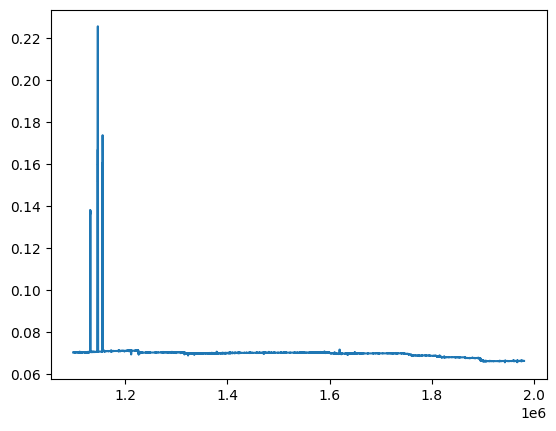

In [11]:
base_df[base_df["datetime"] >= "2025-10-01"]["borrow_rate_after"].plot()

In [13]:
import json
with open("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/assets_meta.json", 'r') as f:
    assets_meta = json.load(f)
assets_meta.keys()

dict_keys(['0xdAC17F958D2ee523a2206206994597C13D831ec7', '0x7f39C581F595B53c5cb19bD0b3f8dA6c935E2Ca0', '0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48', '0x4956b52aE2fF65D74CA2d61207523288e4528f96', '0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2', '0x2260FAC5E5542a773Aa44fBCfeDf7C193bc2C599', '0x833589fCD6eDb6E08f4c7C32D4f71b54bdA02913', '0xcbB7C0000aB88B473b1f5aFd9ef808440eed33Bf', '0x7CF9DEC92ca9FD46f8d86e7798B72624Bc116C05', '0xaF76B3AF3477E4a2cD0B7F80c3152108c19a25e5', '0x3EAA0F0f0A5d3D595ae4e4b0D27f439d01c3E7b2', '0x5086bf358635B81D8C47C66d1C8b9E567Db70c72', '0x88887bE419578051FF9F4eb6C858A951921D8888', '0x1202F5C7b4B9E47a1A484E8B270be34dbbC75055', '0x6c3ea9036406852006290770BEdFcAbA0e23A0e8', '0x80ac24aA929eaF5013f6436cdA2a7ba190f5Cc0b', '0x6B175474E89094C44Da98b954EedeAC495271d0F', '0x4c9EDD5852cd905f086C759E8383e09bff1E68B3', '0xDBDC1Ef57537E34680B898E1FEBD3D68c7389bCB', '0x9b5528528656DBC094765E2abB79F293c21191B9', '0x66a1E37c9b0eAddca17d3662D6c05F4DECf3e110', '0x4737D9b4592B40d51e11

In [14]:
fixed = {}
for i in assets_meta.keys():
    if i != '0x833589fCD6eDb6E08f4c7C32D4f71b54bdA02913':
        fixed[i] = assets_meta[i]
        continue
    nw = assets_meta[i]
    nw["symbol"] = "USDC"
    nw["decimals"] = 6
    for j in range(len(nw["historical_price"])):
        nw["historical_price"][j][1] = 1 
    print(nw)
    fixed[i] = nw 

{'asset_assress': '0x833589fCD6eDb6E08f4c7C32D4f71b54bdA02913', 'decimals': 6, 'symbol': 'USDC', 'historical_price': [[1746237600, 1], [1746241200, 1], [1746244800, 1], [1746248400, 1], [1746252000, 1], [1746255600, 1], [1746259200, 1], [1746262800, 1], [1746266400, 1], [1746270000, 1], [1746273600, 1], [1746277200, 1], [1746280800, 1], [1746284400, 1], [1746288000, 1], [1746291600, 1], [1746295200, 1], [1746298800, 1], [1746302400, 1], [1746306000, 1], [1746309600, 1], [1746313200, 1], [1746316800, 1], [1746320400, 1], [1746324000, 1], [1746327600, 1], [1746331200, 1], [1746334800, 1], [1746338400, 1], [1746342000, 1], [1746345600, 1], [1746349200, 1], [1746352800, 1], [1746356400, 1], [1746360000, 1], [1746363600, 1], [1746367200, 1], [1746370800, 1], [1746374400, 1], [1746378000, 1], [1746381600, 1], [1746385200, 1], [1746388800, 1], [1746392400, 1], [1746396000, 1], [1746399600, 1], [1746403200, 1], [1746406800, 1], [1746410400, 1], [1746414000, 1], [1746417600, 1], [1746421200, 1]

In [15]:
with open("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/assets_meta.json", 'w') as f:
    json.dump(fixed, f, indent=4)


In [1]:
import pandas as pd
def save_dict_of_dfs(data_dict, base_dir='data'):
    """
    Save dict of DataFrames to directory structure.
    
    Parameters:
    data_dict: dict with keys, each value is list of DataFrames
    base_dir: root directory to save to
    """
    import os
    import pandas as pd
    
    for key, df_list in data_dict.items():
        key_dir = os.path.join(base_dir, key)
        os.makedirs(key_dir, exist_ok=True)
        
        for i, df in enumerate(df_list):
            filename = os.path.join(key_dir, f'{i}.parquet')
            df.to_parquet(filename)
            print(f"Saved {key}/{i}.parquet")

def load_dict_of_dfs(base_dir='data'):
    """
    Load dict of DataFrames from directory structure.
    """
    import os
    import pandas as pd
    
    data_dict = {}
    for key in os.listdir(base_dir):
        key_dir = os.path.join(base_dir, key)
        if os.path.isdir(key_dir):
            df_list = []
            for fname in sorted(os.listdir(key_dir)):
                if fname.endswith('.parquet'):
                    df_list.append(pd.read_parquet(os.path.join(key_dir, fname)))
            data_dict[key] = df_list
    return data_dict
load_dict_of_dfs("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/dfs_for_models/hourly_small")

{'risky': [                                     user_address   timestamp  \
  0      0x0002f95Bc5D92B33e2f70EF99808c57637355484  1736336843   
  2      0x0002f95Bc5D92B33e2f70EF99808c57637355484  1736344043   
  3      0x0002f95Bc5D92B33e2f70EF99808c57637355484  1736347643   
  6      0x0002f95Bc5D92B33e2f70EF99808c57637355484  1736358443   
  7      0x0002f95Bc5D92B33e2f70EF99808c57637355484  1736362043   
  ...                                           ...         ...   
  86393  0xf99C8873B972b4192e789F55AB954188D0d9A133  1738513071   
  86400  0xf99C8873B972b4192e789F55AB954188D0d9A133  1738538271   
  86401  0xf99C8873B972b4192e789F55AB954188D0d9A133  1738541871   
  86403  0xf99C8873B972b4192e789F55AB954188D0d9A133  1738549071   
  86404  0xf99C8873B972b4192e789F55AB954188D0d9A133  1738552671   
  
                   datetime  collateral           debt  supply       ltv  \
  0     2025-01-08 11:47:23    0.009020     619.150000     0.0  0.715745   
  2     2025-01-08 13:47:23    0